# Chapter 11: Grover Algorithms

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,transpile
from IPython.display import display
from qiskit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import grover_operator


from Chapter08_QuantumGates_functions import (simulate_measurements, estimateCircuitGates)



## Phase Kickback Barebones

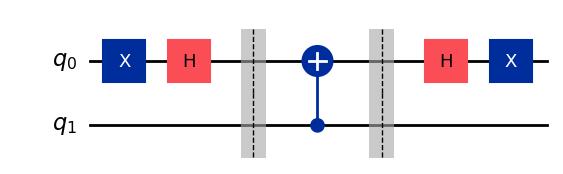

In [2]:
circuit = QuantumCircuit(2)  
circuit.x(0)
circuit.h(0)
circuit.barrier()
circuit.cx(1,0)
circuit.barrier()
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))

## Phase Kickback Example

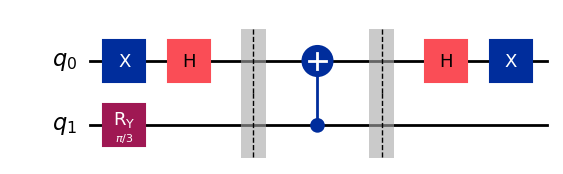

<IPython.core.display.Latex object>

In [3]:
circuit = QuantumCircuit(2)  
circuit.x(0)
circuit.h(0)
circuit.ry(theta = np.pi/3, qubit=1) 
circuit.barrier()
circuit.cx(1,0)
circuit.barrier()
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

## Phase Oracle Barebones

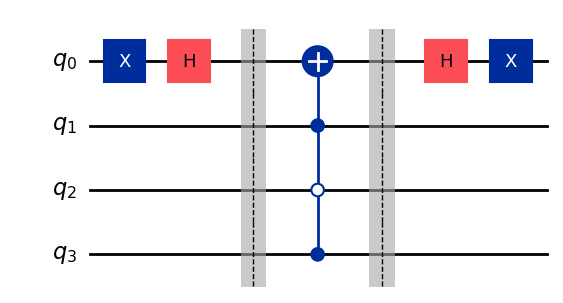

<IPython.core.display.Latex object>

In [4]:
# 4 Qubits: q0 is Ancilla, q1-q3 are Input
circuit = QuantumCircuit(4)

# 1. Prepare Ancilla (q0) in the |-> state
circuit.x(0)
circuit.h(0)
circuit.barrier()

# 2. Phase Oracle for |101> 
# Input register is (q3, q2, q1). For |101>, q2 must be flipped.
circuit.mcx([1, 2, 3], 0, ctrl_state = '101')   # Controls: q1,q2,q3. Target: q0
circuit.barrier()

# 3. Clean up Ancilla to return it to |0>
circuit.h(0)
circuit.x(0)

display(circuit.draw('mpl'))

# Verify the result
# The statevector will show a negative sign on the |1010> state 
# (where the last 0 is the ancilla q0)
psi = Statevector(circuit)
display(psi.draw('latex'))

## Phase oracle example

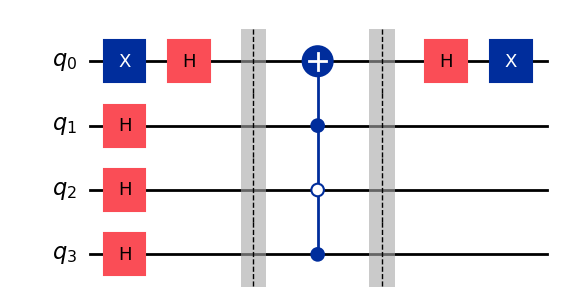

<IPython.core.display.Latex object>

In [5]:
# 4 Qubits: q0 is Ancilla, q1-q3 are Input
circuit = QuantumCircuit(4)

# 1. Prepare Ancilla (q0) in the |-> state
circuit.x(0)
circuit.h(0)

for qubit in [1, 2, 3]:
    circuit.h(qubit)
circuit.barrier()
# 2. Phase Oracle for |101> 
# Input register is (q3, q2, q1). For |101>, q2 must be flipped.
circuit.mcx([1, 2, 3], 0, ctrl_state = '101')   # Controls: q1,q2,q3. Target: q0
circuit.barrier()

# 3. Clean up Ancilla to return it to |0>
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))

# Verify the result
# The statevector will show a negative sign on the |1010> state 
# (where the last 0 is the ancilla q0)
psi = Statevector(circuit)
display(psi.draw('latex'))

## Qiskit's Built-in PhaseOracleGate

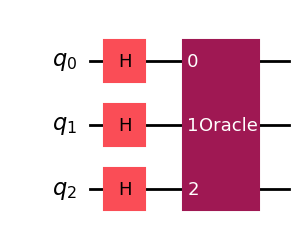

<IPython.core.display.Latex object>

In [6]:
from qiskit.circuit.library import PhaseOracleGate
from Chapter12_GroverAlgorithm_functions import get_qiskit_expression

expression = 'x2 & ~x1 & ~x0' # state 100
qiskit_expr = get_qiskit_expression(expression, 3)

oracle_gate = PhaseOracleGate(qiskit_expr,label='Oracle')

# Now just add it to your main circuit
n = 3 # Don't include ancilla
circuit = QuantumCircuit(n)
for qubit in range(n):
    circuit.h(qubit)
circuit.append(oracle_gate, range(n))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

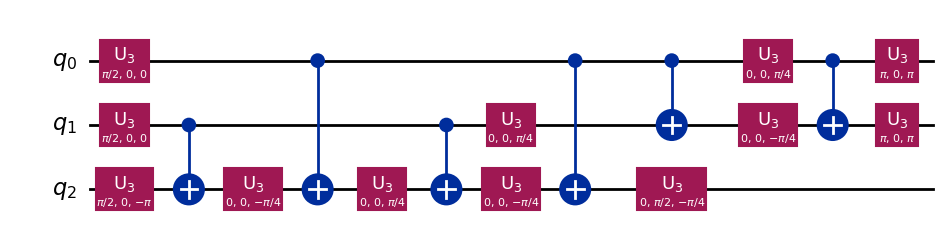

{'num_qubits': 3, 'single_gate_count': 12, 'cx_gates': 6, 'total_gates': 18, 'depth': 12, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000211AAD5CD90>}


In [7]:
from Chapter08_QuantumGates_functions import  estimateCircuitGates

transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
display(transpiled_circuit.draw('mpl'))
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

### Boolean expressions

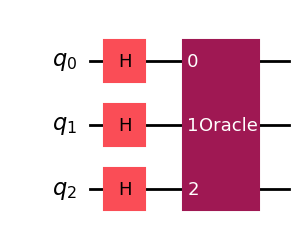

<IPython.core.display.Latex object>

In [8]:
expression = '(x2 & ~x1 & ~x0) | (x2 & ~x1 & x0)' # states 100 and 101
expression = '(x2 | x0)' # 
qiskit_expr = get_qiskit_expression(expression, 3)

oracle_gate = PhaseOracleGate(qiskit_expr,label='Oracle')

# Now just add it to your main circuit
n = 3 # Don't include ancilla
circuit = QuantumCircuit(n)
for qubit in range(n):
    circuit.h(qubit)
circuit.append(oracle_gate, range(n))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

### Transpiled circuit

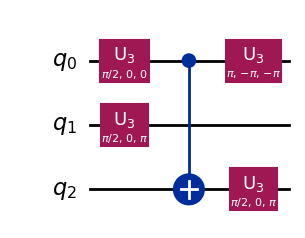

{'num_qubits': 3, 'single_gate_count': 4, 'cx_gates': 1, 'total_gates': 5, 'depth': 3, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000211AAD45D90>}


In [9]:
transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
display(transpiled_circuit.draw('mpl'))
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

## Feasible trusses

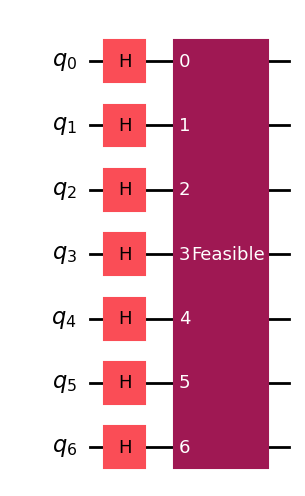

<IPython.core.display.Latex object>

In [10]:
n_members = 7
feasible_expr = "(x0 | x1 | x2) & (x0 | x3 | x4)"
# Ensure string variables are in the correct order for the oracle
qiskit_expr = get_qiskit_expression(feasible_expr, n_members)

oracle_gate = PhaseOracleGate(qiskit_expr,label="Feasible")
circuit = QuantumCircuit(n_members)
for qubit in range(n_members):
    circuit.h(qubit)
circuit.append(oracle_gate,range(n_members))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))


In [11]:
transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

{'num_qubits': 7, 'single_gate_count': 73, 'cx_gates': 60, 'total_gates': 133, 'depth': 108, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000211AB0520D0>}


## Single feasible truss design problem
## Classical solution

In [12]:
from Chapter12_GroverAlgorithm_functions import get_feasible_expression

n_members = 7
# generate a Boolean expression with one feasible solution
feasible_expr = get_feasible_expression() 
count = 0
for i in range(2**n_members):
    x0, x1, x2, x3, x4, x5, x6 = [int(b) for b in format(i, '07b')]
    if eval(feasible_expr):
        count += 1
        members = [j for j, b in enumerate([x0,x1,x2,x3,x4,x5,x6]) if b]
        bitstring = format(i,'07b')[::-1]  # reverse to match Qiskit ket order
        print(f"Solution: x0..x6 = {bitstring} -> active members {members}")

print(f"Total solutions: {count}")

Solution: x0..x6 = 1101101 -> active members [0, 2, 3, 5, 6]
Total solutions: 1


## Grover algorithm

Optimal number of Grover iterations: 8
{'1101101': 994, '0111001': 1, '1100010': 2, '1100001': 1, '0011101': 1, '0000100': 1}


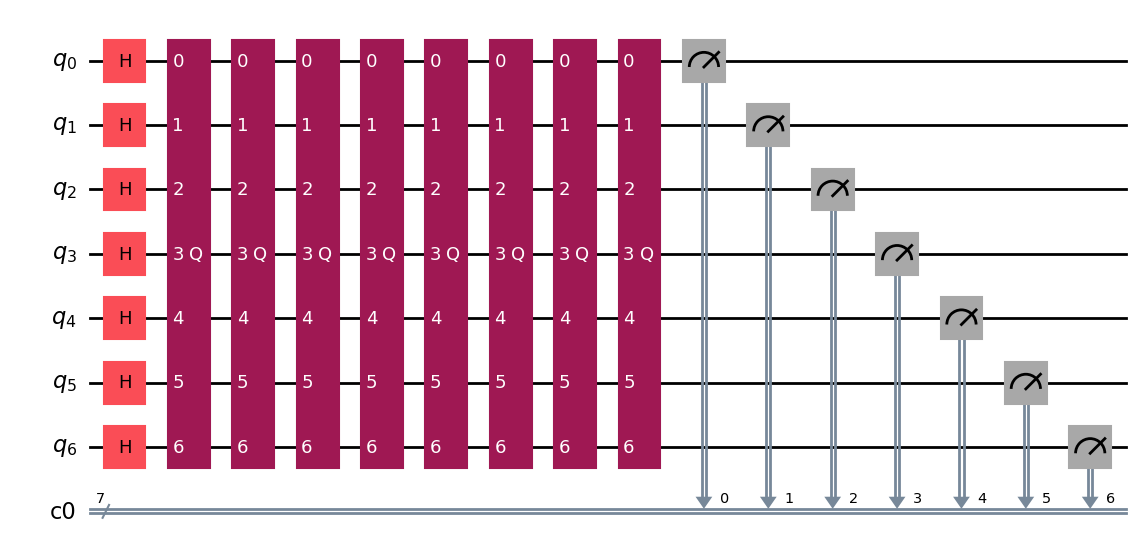

In [13]:
qiskit_expr = get_qiskit_expression(feasible_expr, n_members)

oracle = PhaseOracleGate(qiskit_expr,label="Feasible")
grover_op = grover_operator(oracle)

n_members  = 7
N = 2**n_members
K = math.floor(math.pi / (4 * math.asin(math.sqrt(1 / N))))
print("Optimal number of Grover iterations:", K)

qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(n_members))  # only superpose the search qubits, not ancillas
qc.compose(grover_op.power(K), inplace=True)

cr = ClassicalRegister(n_members)
qc.add_register(cr)
for i in range(n_members):
    qc.measure(i, cr[i])
counts = simulate_measurements(qc, shots=1000)
print(counts)
display(qc.draw('mpl'))

## Grover circuit Analysis

### High level depth

In [14]:
print("width:", qc.width()) # includes ancillas
print("depth:", qc.depth()) # high level functions only

width: 14
depth: 10


### Estimate circuit width and depth

In [15]:
info = estimateCircuitGates(qc)
print("Grover Circuit:", info)

Grover Circuit: {'num_qubits': 7, 'single_gate_count': 2417, 'cx_gates': 2180, 'total_gates': 4597, 'depth': 2984, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000211AC968F90>}


### Probability of success vs K

theta  = 0.088504 rad
K_opt  = 8
Period = pi/(2*theta) ≈ 17.7 iterations


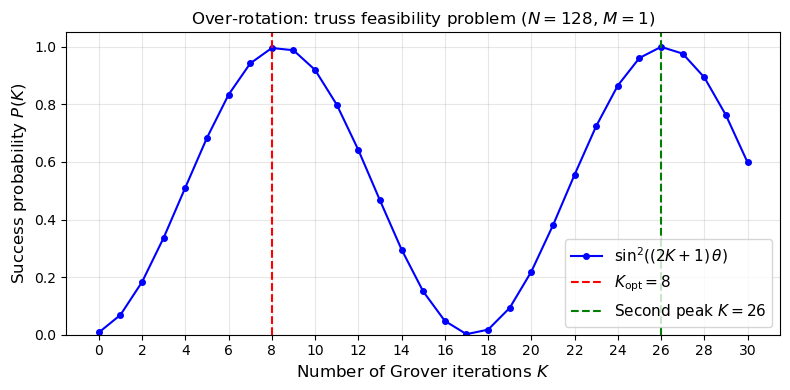

Saved: grover_overrotation.png

  K      P(K)
 --      ----
  0    0.0078
  1    0.0689
  2    0.1834
  3    0.3372
  4    0.5111
  5    0.6837
  6    0.8335
  7    0.9420
  8    0.9956 <-- K_opt
  9    0.9878
 10    0.9194
 11    0.7991
 12    0.6416
 13    0.4666
 14    0.2957
 15    0.1502
 16    0.0480
 17    0.0019
 18    0.0176
 19    0.0931
 20    0.2191
 21    0.3799
 22    0.5556
 23    0.7244
 24    0.8654
 25    0.9610
 26    0.9995 <-- 2nd peak
 27    0.9761
 28    0.8936
 29    0.7622
 30    0.5984


In [16]:
from Chapter12_GroverAlgorithm_functions import (
    bitstring_to_expression, get_qiskit_expression
)
# ── Setup ──────────────────────────────────────────────────────────────────────
n_members = 7
N         = 2**n_members
TARGET    = '1101101'        # the single feasible truss design
 
feasible_expr = bitstring_to_expression(TARGET)
qiskit_expr   = get_qiskit_expression(feasible_expr, n_members)
 
oracle    = PhaseOracleGate(qiskit_expr, label="Feasible")
grover_op = grover_operator(oracle)
 
theta = math.asin(1 / math.sqrt(N))
K_opt = math.floor(math.pi / (4 * theta) - 0.5)
print(f"theta  = {theta:.6f} rad")
print(f"K_opt  = {K_opt}")
print(f"Period = pi/(2*theta) ≈ {math.pi / (2 * theta):.1f} iterations")
 
# ── Probability sweep K = 0 … 30 ──────────────────────────────────────────────
K_range = range(31)
P_theory = [math.sin((2*K + 1) * theta)**2 for K in K_range]
 
P_exact = []
for K in K_range:
    qc = QuantumCircuit(grover_op.num_qubits)
    qc.h(range(n_members))
    if K > 0:
        qc.compose(grover_op.power(K), inplace=True)
    sv    = Statevector(qc)
    probs = sv.probabilities_dict(qargs=list(range(n_members)))
    P_exact.append(probs.get(TARGET, 0.0))
 
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.plot(K_range, P_theory, 'b-o', markersize=4, label=r'$\sin^2\!((2K+1)\,\theta)$')
ax.axvline(K_opt, color='red',  linestyle='--', linewidth=1.5,
           label=f'$K_{{\\rm opt}} = {K_opt}$')
ax.axvline(26,    color='green', linestyle='--', linewidth=1.5,
           label=f'Second peak $K = 26$')
 
ax.set_xlabel('Number of Grover iterations $K$', fontsize=12)
ax.set_ylabel('Success probability $P(K)$',       fontsize=12)
ax.set_title('Over-rotation: truss feasibility problem ($N=128$, $M=1$)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xticks(range(0, 31, 2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('grover_overrotation.png', dpi=150)
plt.show()
print("Saved: grover_overrotation.png")
 
# ── Print key values ───────────────────────────────────────────────────────────
print(f"\n{'K':>3}  {'P(K)':>8}")
print(f"{'--':>3}  {'----':>8}")
for K in K_range:
    marker = " <-- K_opt" if K == K_opt else (" <-- 2nd peak" if K == 26 else "")
    print(f"{K:3d}  {P_theory[K]:8.4f}{marker}")

## Void Detection

### Example

Target inclusion fraction: 0.010
Actual inclusion fraction: 0.012


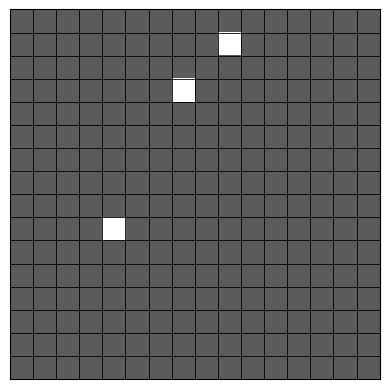

In [17]:
from Chapter03_EngineeringOptimization_functions import MicrostructureGenerator

microstructure = MicrostructureGenerator(nx=16, ny=16, inclusion_fraction=0.01, micro_type='random_elements')
microstructure.plot()

### String from microstructure

In [ ]:
from Chapter12_GroverAlgorithm_functions import get_void_expression


# ── Cell 2: Coordinate encoding ───────────────────────────────────────────────
expression, n_qubits, void_coords, all_vars = get_void_expression(grid=microstructure.data)
 
grid_array = np.array(microstructure.data)
rows, cols = grid_array.shape
m = int(np.log2(rows))          # register size: rows = cols = 2^m
N = rows * cols                 # search space: N coordinate pairs
M = len(void_coords)            # marked states: one per void
 
print(f"Grid        : {rows} x {cols}  (m={m})")
print(f"Search space: N = {N} coordinate pairs")
print(f"Qubits      : 2m = {n_qubits}  (vs {N} for flat encoding)")
print(f"Voids (M={M}): {void_coords}")
print()

Grid        : 16 x 16  (m=4)
Search space: N = 256 coordinate pairs
Qubits      : 2m = 8  (vs 256 for flat encoding)
Voids (M=3): [(6, 4), (12, 7), (14, 9)]

Oracle expression:
(~xi0 & xi1 & xi2 & ~xi3 & ~xj0 & ~xj1 & xj2 & ~xj3) | (~xi0 & ~xi1 & xi2 & xi3 & xj0 & xj1 & xj2 & ~xj3) | (~xi0 & xi1 & xi2 & xi3 & xj0 & ~xj1 & ~xj2 & xj3)


## Grover on microstructure

In [19]:
from qiskit.circuit.library import PhaseOracleGate
from Chapter12_GroverAlgorithm_functions import decode_void_measurement
 

qiskit_expr = get_qiskit_expression(expression, n_qubits, prefix_vars=all_vars)

 
oracle    = PhaseOracleGate(qiskit_expr, label="Void")
grover_op = grover_operator(oracle)
 
# Optimal K -- Eq. (12.4) for M solutions in search space of size N
theta = math.asin(math.sqrt(M / N))
K     = max(1, math.floor(math.pi / (4 * theta) - 0.5))
print(f"Optimal Grover iterations K = {K}")
 
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(n_qubits))
qc.compose(grover_op.power(K), inplace=True)
cr = ClassicalRegister(n_qubits)
qc.add_register(cr)
for i in range(n_qubits):
    qc.measure(i, cr[i])
 
counts = simulate_measurements(qc, shots=1000)
 
# Decode bitstrings back to (row, col) coordinates
print("\nMeasurement results (bitstring -> (row, col) : count):")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1]):
    row, col = decode_void_measurement(bitstring, m)
    marker = " <-- void" if (row, col) in void_coords else ""
    print(f"  {bitstring} -> ({row},{col}) : {count}{marker}")
 

Optimal Grover iterations K = 6

Measurement results (bitstring -> (row, col) : count):
  01111100 -> (12,7) : 343 <-- void
  10011110 -> (14,9) : 325 <-- void
  01000110 -> (6,4) : 317 <-- void
  00001101 -> (13,0) : 1
  01101000 -> (8,6) : 1
  00101101 -> (13,2) : 1
  00100010 -> (2,2) : 1
  01110110 -> (6,7) : 1
  10110110 -> (6,11) : 1
  10000011 -> (3,8) : 1
  10110001 -> (1,11) : 1
  01001001 -> (9,4) : 1
  10111101 -> (13,11) : 1
  11000110 -> (6,12) : 1
  11001011 -> (11,12) : 1
  01101011 -> (11,6) : 1
  10010110 -> (6,9) : 1
  10001110 -> (14,8) : 1
